In [1]:
%pip install -q pandas pyarrow numpy statsmodels seaborn matplotlib tqdm

You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [2]:
try:
    import pandas as pd
    import numpy as np
    import os
    from pathlib import Path

    for fpath in ["data/raw_prices.parquet", "data/sentiment_daily.parquet"]:
        if not Path(fpath).exists():
            nb = "notebook_01" if "prices" in fpath else "notebook_02"
            raise FileNotFoundError(f"{fpath} not found — run {nb} first")

    df_prices = pd.read_parquet("data/raw_prices.parquet")
    df_sentiment = pd.read_parquet("data/sentiment_daily.parquet")

    print(f"raw_prices:        {df_prices.shape}  columns: {list(df_prices.columns)}")
    print(f"sentiment_daily:   {df_sentiment.shape}  columns: {list(df_sentiment.columns)}")
except Exception as e:
    print(f"\n[ERROR] {type(e).__name__}: {e}")
    raise SystemExit(1) from None

raw_prices:        (20140, 8)  columns: ['date', 'ticker', 'open', 'high', 'low', 'close', 'volume', 'log_return']
sentiment_daily:   (7817, 6)  columns: ['date', 'ticker', 'sentiment_score', 'article_count', 'avg_finbert_score', 'avg_lm_score']


In [3]:
try:
    df_prices["date"] = pd.to_datetime(df_prices["date"])
    df_sentiment["date"] = pd.to_datetime(df_sentiment["date"])

    df_merged = df_prices.merge(df_sentiment[["date", "ticker", "sentiment_score"]], on=["date", "ticker"], how="inner")
    df_merged = df_merged.sort_values(["ticker", "date"]).reset_index(drop=True)

    TICKERS = sorted(df_merged["ticker"].unique().tolist())
    print(f"Merged dataset: {len(df_merged)} rows, {len(TICKERS)} tickers")
    print(f"TICKERS: {TICKERS}")
except Exception as e:
    print(f"\n[ERROR] {type(e).__name__}: {e}")
    raise SystemExit(1) from None

Merged dataset: 7601 rows, 10 tickers
TICKERS: ['AAPL', 'AMD', 'AMZN', 'GOOGL', 'INTC', 'META', 'MSFT', 'NFLX', 'NVDA', 'TSLA']


In [4]:
try:
    from statsmodels.tsa.stattools import adfuller

    def run_adf(series):
        s = series.dropna()
        if len(s) < 2:
            return (np.nan, np.nan, False)
        try:
            stat, pval, *_ = adfuller(s, autolag="AIC")
            return (float(stat), float(pval), pval < 0.05)
        except Exception as exc:
            print(f"  ADF exception ({exc}) — treating as non-stationary")
            return (np.nan, np.nan, False)

    adf_records = []
    for t in TICKERS:
        series = df_merged.loc[df_merged["ticker"] == t, "log_return"]
        stat, pval, is_stat = run_adf(series)
        adf_records.append({"ticker": t, "adf_statistic": stat, "p_value": pval, "is_stationary": is_stat})

    df_adf = pd.DataFrame(adf_records)

    print("=== ADF Stationarity Test Results ===")
    print(df_adf.to_string(index=False))
    n_stat = df_adf["is_stationary"].sum()
    print(f"\n{n_stat}/{len(df_adf)} tickers have stationary log_return series (p < 0.05)")
    print(f"{len(df_adf) - n_stat} ticker(s) will be differenced before Granger test")
except Exception as e:
    print(f"\n[ERROR] {type(e).__name__}: {e}")
    raise SystemExit(1) from None

=== ADF Stationarity Test Results ===
ticker  adf_statistic      p_value  is_stationary
  AAPL      -9.109618 3.427598e-15           True
   AMD     -13.005869 2.628628e-24           True
  AMZN     -12.991426 2.807237e-24           True
 GOOGL     -10.730551 2.987548e-19           True
  INTC     -12.597705 1.763883e-23           True
  META     -11.774848 1.068496e-21           True
  MSFT      -8.780444 2.384680e-14           True
  NFLX     -11.069086 4.601783e-20           True
  NVDA     -13.569176 2.232112e-25           True
  TSLA     -28.009669 0.000000e+00           True

10/10 tickers have stationary log_return series (p < 0.05)
0 ticker(s) will be differenced before Granger test


In [5]:
try:
    from statsmodels.tsa.stattools import grangercausalitytests

    MIN_ROWS = 60
    MAXLAG = 5

    granger_records = []

    for t in TICKERS:
        sub = df_merged[df_merged["ticker"] == t][["log_return", "sentiment_score"]].copy()

        is_stationary = df_adf.loc[df_adf["ticker"] == t, "is_stationary"].values[0]
        if not is_stationary:
            sub["log_return"] = sub["log_return"].diff()

        sub = sub.dropna()

        if len(sub) < MIN_ROWS:
            print(f"WARNING: {t} has {len(sub)} rows after prep — skipping (insufficient_data)")
            granger_records.append({
                "ticker": t,
                "granger_verified": False,
                "optimal_lag": None,
                "min_p_value": None,
                "p_value_lag1": None,
                "p_value_lag2": None,
                "p_value_lag3": None,
                "p_value_lag4": None,
                "p_value_lag5": None,
                "skip_reason": "insufficient_data",
            })
            continue

        results = grangercausalitytests(sub[["log_return", "sentiment_score"]], maxlag=MAXLAG, verbose=False)
        p_vals = {lag: results[lag][0]["ssr_ftest"][1] for lag in range(1, MAXLAG + 1)}

        min_p = min(p_vals.values())
        opt_lag = min(p_vals, key=p_vals.get)

        granger_records.append({
            "ticker": t,
            "granger_verified": bool(min_p < 0.05),
            "optimal_lag": int(opt_lag),
            "min_p_value": float(min_p),
            "p_value_lag1": float(p_vals[1]),
            "p_value_lag2": float(p_vals[2]),
            "p_value_lag3": float(p_vals[3]),
            "p_value_lag4": float(p_vals[4]),
            "p_value_lag5": float(p_vals[5]),
            "skip_reason": None,
        })

    df_granger = pd.DataFrame(granger_records)
    print(f"Granger tests complete: {df_granger['granger_verified'].sum()}/{len(df_granger)} verified")
except Exception as e:
    print(f"\n[ERROR] {type(e).__name__}: {e}")
    raise SystemExit(1) from None

Granger tests complete: 3/10 verified


/Users/dhruvansh/Library/Python/3.9/lib/python/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/Users/dhruvansh/Library/Python/3.9/lib/python/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/Users/dhruvansh/Library/Python/3.9/lib/python/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/Users/dhruvansh/Library/Python/3.9/lib/python/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/Users/dhruvansh/Library/Python/3.9/lib/python/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/Users/dhruvansh/Library/Python/3.9/lib/pytho

In [13]:
try:
    col_order = [
        "ticker", "granger_verified", "optimal_lag", "min_p_value",
        "p_value_lag1", "p_value_lag2", "p_value_lag3", "p_value_lag4", "p_value_lag5",
        "skip_reason",
    ]
    df_granger = df_granger[col_order]

    os.makedirs("data", exist_ok=True)
    df_granger.to_parquet("data/granger_results.parquet", index=False)
    print(f"Saved data/granger_results.parquet — {len(df_granger)} rows")
except Exception as e:
    print(f"\n[ERROR] {type(e).__name__}: {e}")
    raise SystemExit(1) from None

Saved data/granger_results.parquet — 10 rows


In [14]:
try:
    df_prices["date"] = pd.to_datetime(df_prices["date"])
    df_pivot = df_prices.pivot(index="date", columns="ticker", values="log_return")

    def lead_lag_score(s_i, s_j):
        """
        L(i,j) = sum(k * corr(i, j.shift(k))  for k in -10..10)
        NaN dates dropped per pair individually.
        Positive score means i leads j.
        """
        combined = pd.DataFrame({"i": s_i, "j": s_j}).dropna()
        if len(combined) < 2:
            print(f"  WARNING: insufficient overlap for pair — setting score to 0.0")
            return 0.0
        score = 0.0
        for k in range(-10, 11):
            corr = combined["i"].corr(combined["j"].shift(k))
            if pd.isna(corr):
                corr = 0.0
            score += k * corr  # no /n — division made all scores ~0 (order 1/2000)
        return score

    print("lead_lag_score defined")
    print(f"Price pivot shape: {df_pivot.shape} ({df_pivot.shape[1]} tickers × {df_pivot.shape[0]} dates)")
except Exception as e:
    print(f"\n[ERROR] {type(e).__name__}: {e}")
    raise SystemExit(1) from None

lead_lag_score defined
Price pivot shape: (2014, 10) (10 tickers × 2014 dates)


In [15]:
try:
    from tqdm import tqdm

    matrix = {}
    for ti in tqdm(TICKERS, desc="Computing lead-lag matrix"):
        matrix[ti] = {}
        for tj in TICKERS:
            if ti == tj:
                matrix[ti][tj] = 0.0
            elif ti not in df_pivot.columns or tj not in df_pivot.columns:
                print(f"  WARNING: {ti} or {tj} missing from price data — setting 0.0")
                matrix[ti][tj] = 0.0
            else:
                matrix[ti][tj] = lead_lag_score(df_pivot[ti], df_pivot[tj])

    df_ll = pd.DataFrame(matrix, index=TICKERS, columns=TICKERS)
    print(f"Lead-lag matrix shape: {df_ll.shape}")
    print(f"Diagonal sum (should be 0.0): {df_ll.values.diagonal().sum():.6f}")
    print(f"Non-zero off-diagonal entries: {(df_ll.values != 0).sum() - len(TICKERS)}")
except Exception as e:
    print(f"\n[ERROR] {type(e).__name__}: {e}")
    raise SystemExit(1) from None

Computing lead-lag matrix: 100%|██████████| 10/10 [00:00<00:00, 61.04it/s]

Lead-lag matrix shape: (10, 10)
Diagonal sum (should be 0.0): 0.000000
Non-zero off-diagonal entries: 80


In [16]:
try:
    os.makedirs("data", exist_ok=True)
    df_ll.to_parquet("data/lead_lag_matrix.parquet")
    print(f"Saved data/lead_lag_matrix.parquet — {df_ll.shape[0]}×{df_ll.shape[1]} matrix")
except Exception as e:
    print(f"\n[ERROR] {type(e).__name__}: {e}")
    raise SystemExit(1) from None

Saved data/lead_lag_matrix.parquet — 10×10 matrix


In [17]:
try:
    df_gr = pd.read_parquet("data/granger_results.parquet")

    def fmt_p(row):
        lag = row["optimal_lag"]
        if pd.isna(lag):
            return "—"
        col = f"p_value_lag{int(lag)}"
        val = row.get(col)
        return f"{val:.4f}" if pd.notna(val) else "—"

    df_display = df_gr[["ticker", "granger_verified", "optimal_lag", "min_p_value", "skip_reason"]].copy()
    df_display["p_at_optimal_lag"] = df_gr.apply(fmt_p, axis=1)
    df_display["min_p_value"] = df_display["min_p_value"].map(lambda x: f"{x:.4f}" if pd.notna(x) else "—")
    df_display["skip_reason"] = df_display["skip_reason"].fillna("")

    print("\n=== Granger Causality Results ===")
    print(df_display[["ticker", "granger_verified", "optimal_lag", "p_at_optimal_lag", "min_p_value", "skip_reason"]].to_string(index=False))

    verified = df_gr["granger_verified"].sum()
    print(f"\n{verified}/{len(df_gr)} tickers show Granger-verified sentiment lead (p < 0.05)")
except Exception as e:
    print(f"\n[ERROR] {type(e).__name__}: {e}")
    raise SystemExit(1) from None


=== Granger Causality Results ===
ticker  granger_verified  optimal_lag p_at_optimal_lag min_p_value skip_reason
  AAPL             False            1           0.0646      0.0646            
   AMD             False            5           0.4110      0.4110            
  AMZN              True            2           0.0312      0.0312            
 GOOGL             False            3           0.1764      0.1764            
  INTC              True            1           0.0326      0.0326            
  META             False            1           0.3323      0.3323            
  MSFT             False            1           0.6906      0.6906            
  NFLX              True            1           0.0003      0.0003            
  NVDA             False            3           0.1013      0.1013            
  TSLA             False            1           0.2922      0.2922            

3/10 tickers show Granger-verified sentiment lead (p < 0.05)


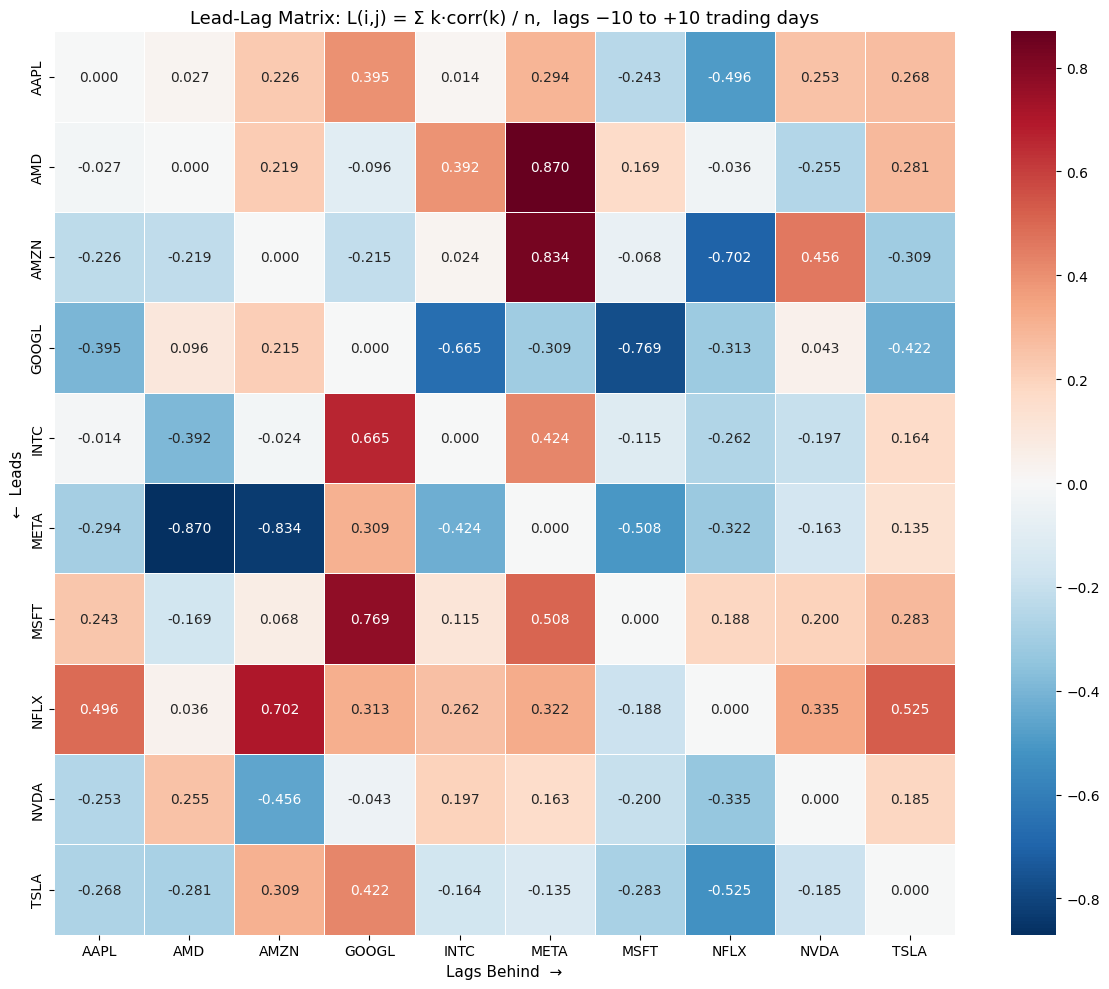

In [18]:
try:
    import seaborn as sns
    import matplotlib.pyplot as plt

    df_ll_plot = pd.read_parquet("data/lead_lag_matrix.parquet")

    fig, ax = plt.subplots(figsize=(12, 10))
    sns.heatmap(
        df_ll_plot,
        cmap="RdBu_r",
        center=0,
        annot=True,
        fmt=".3f",
        linewidths=0.5,
        ax=ax,
    )
    ax.set_title("Lead-Lag Matrix: L(i,j) = Σ k·corr(k) / n,  lags −10 to +10 trading days", fontsize=13)
    ax.set_xlabel("Lags Behind  →", fontsize=11)
    ax.set_ylabel("←  Leads", fontsize=11)
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"\n[ERROR] {type(e).__name__}: {e}")
    raise SystemExit(1) from None

## EDA — Granger & Lead-Lag Exploratory Plots

In [ ]:

# EDA 9 — Granger Causality p-values Bar Chart
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
import numpy as np
import os

os.makedirs("outputs", exist_ok=True)
df_gr = pd.read_parquet("data/granger_results.parquet")
df_gr = df_gr.sort_values("min_p_value")

fig, ax = plt.subplots(figsize=(11, 5))
bar_colors = ['#2ecc71' if v else '#e74c3c' for v in df_gr["granger_verified"]]
bars = ax.bar(df_gr["ticker"], df_gr["min_p_value"], color=bar_colors, edgecolor='white', linewidth=0.8)
ax.axhline(0.05, color='black', linestyle='--', linewidth=1.5, label='α = 0.05 significance threshold')

for bar, row in zip(bars, df_gr.itertuples()):
    pval = row.min_p_value if row.min_p_value is not None and not np.isnan(row.min_p_value) else 0
    ax.text(bar.get_x() + bar.get_width()/2,
            min(pval + 0.01, 0.72),
            f"p={pval:.4f}", ha='center', va='bottom', fontsize=8.5)

green_p = mpatches.Patch(color='#2ecc71', label='Granger Verified (p < 0.05)')
red_p   = mpatches.Patch(color='#e74c3c', label='Not Verified (p ≥ 0.05)')
ax.legend(handles=[green_p, red_p,
                   plt.Line2D([0],[0], color='black', linestyle='--', label='α = 0.05')],
          fontsize=9)
ax.set_title("Granger Causality Min p-Values: Sentiment → Price Return (lags 1–5)",
             fontsize=13, fontweight='bold')
ax.set_xlabel("Ticker", fontsize=12)
ax.set_ylabel("Minimum p-value across lags 1–5", fontsize=12)
ax.set_ylim(0, 0.80)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig("outputs/eda_09_granger_pvalues.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved outputs/eda_09_granger_pvalues.png")


In [ ]:

# EDA 10 — Cross-Correlation Function for top lead-lag pair (NFLX → META)
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

df_prices_eda = pd.read_parquet("data/raw_prices.parquet")
df_prices_eda["date"] = pd.to_datetime(df_prices_eda["date"])
pivot = df_prices_eda.pivot(index="date", columns="ticker", values="log_return").dropna()

TICKER_I = "NFLX"
TICKER_J = "META"
MAX_LAG = 15

lags   = range(-MAX_LAG, MAX_LAG + 1)
ccf_vals = []
for k in lags:
    s_i = pivot[TICKER_I]
    s_j = pivot[TICKER_J].shift(k)
    combined = pd.concat([s_i, s_j], axis=1).dropna()
    ccf_vals.append(combined.iloc[:, 0].corr(combined.iloc[:, 1]))

colors_ccf = ['#2ecc71' if k > 0 else ('#e74c3c' if k < 0 else '#aaaaaa') for k in lags]

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(list(lags), ccf_vals, color=colors_ccf, edgecolor='white')
ax.axhline(0, color='black', linewidth=0.8)
ax.axvline(0, color='grey', linestyle=':', linewidth=0.8)

# confidence bands (95%): ±1.96/sqrt(n)
n = len(pivot)
conf = 1.96 / np.sqrt(n)
ax.axhline(conf,  color='blue', linestyle='--', linewidth=1.0, label=f'95% CI (±{conf:.3f})')
ax.axhline(-conf, color='blue', linestyle='--', linewidth=1.0)

ax.set_title(f"Cross-Correlation Function: {TICKER_I} (leads) vs {TICKER_J} (lags)\n"
             f"Positive lag k = {TICKER_I} leads {TICKER_J} by k days",
             fontsize=13, fontweight='bold')
ax.set_xlabel("Lag k (trading days)", fontsize=12)
ax.set_ylabel("Pearson Correlation", fontsize=12)
ax.set_xticks(list(lags))
ax.legend(fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig(f"outputs/eda_10_ccf_{TICKER_I}_{TICKER_J}.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved outputs/eda_10_ccf_{TICKER_I}_{TICKER_J}.png")


In [ ]:

# EDA 11 — Lead-Lag Score Ranked Bar Chart (top pairs, INPUT_TICKER = NFLX)
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

INPUT_TICKER = "NFLX"
df_ll_eda = pd.read_parquet("data/lead_lag_matrix.parquet")

scores = df_ll_eda.loc[INPUT_TICKER].drop(INPUT_TICKER).sort_values(key=abs, ascending=False)

colors_bar = ['steelblue' if v >= 0 else 'tomato' for v in scores.values]
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(scores.index, scores.values, color=colors_bar, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.axvline(0.05,  color='grey', linestyle='--', linewidth=0.8, label='|L|=0.05 edge threshold')
ax.axvline(-0.05, color='grey', linestyle='--', linewidth=0.8)

for bar, val in zip(bars, scores.values):
    ax.text(val + (0.005 if val >= 0 else -0.005),
            bar.get_y() + bar.get_height()/2,
            f"{val:+.3f}", va='center', ha='left' if val >= 0 else 'right', fontsize=10)

ax.set_title(f"Lead-Lag Scores from {INPUT_TICKER} to All Other Tickers\n"
             f"Positive = {INPUT_TICKER} leads the other ticker",
             fontsize=13, fontweight='bold')
ax.set_xlabel("L(NFLX, j) Score", fontsize=12)
ax.legend(fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig(f"outputs/eda_11_leadlag_scores_{INPUT_TICKER}.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved outputs/eda_11_leadlag_scores_{INPUT_TICKER}.png")
